In [2]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import Caltech101
from PIL import Image

def load_image(image_path):
    img = Image.open(image_path)
    if img.mode != "RGB":
        img = img.convert("RGB")  # caltech101数据集中存在灰度图片，统一转换成 RGB
    return img

class ConvertToRGB:
    def __call__(self, img):
        return img.convert("RGB") if img.mode != "RGB" else img

transform = transforms.Compose([
    ConvertToRGB(),  
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 加载数据集
trainset = Caltech101(root="./data", download=True, transform=transform)
testset = Caltech101(root="./data", download=True, transform=transform)

# 生成 DataLoader
trainloader = DataLoader(trainset, batch_size=32, shuffle=True,num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle=False,num_workers=2)

# 获取类别数
num_classes = len(trainset.categories)
print(f"Caltech-101 共有 {num_classes} 个类别")

Files already downloaded and verified
Files already downloaded and verified
Caltech-101 共有 101 个类别


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[5967, 7880, 2183, 2531, 5176, 8671, 3871, 3799, 2526]


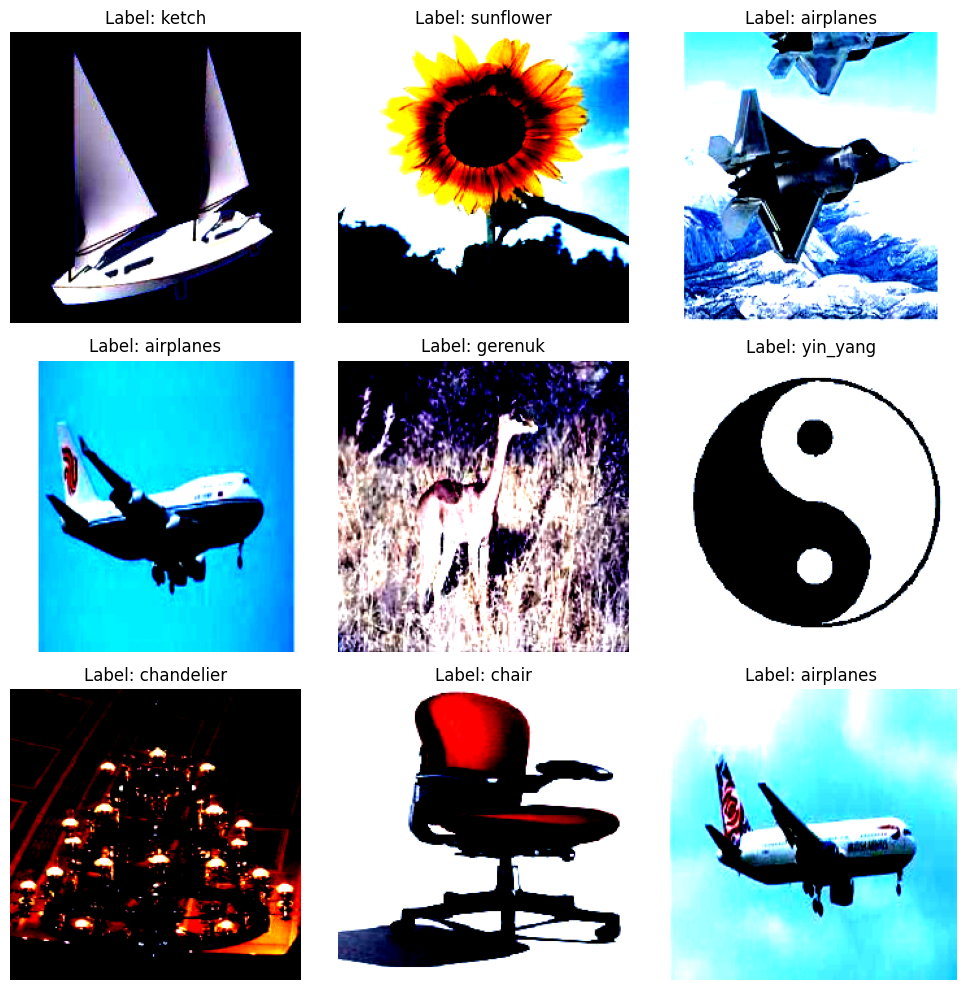

In [4]:
import random
import matplotlib.pyplot as plt

# 可视化数据集样本
def visualize_samples(dataset, num_samples=9):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))

    # 随机选择 num_samples 张图片
    indices = random.sample(range(len(dataset)), num_samples)
    print(indices)
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        ax = axes[i // 3, i % 3]

        # [c,h,w]->[h,w,c]
        image = image.permute(1, 2, 0).numpy()

        # 显示图片
        ax.imshow(image)
        ax.set_title(f"Label: {dataset.categories[label]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 调用可视化函数
visualize_samples(trainset)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 加载预训练的alexnet模型
model = models.alexnet(pretrained=True)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 加载预训练的ResNet-18模型
model = models.alexnet(pretrained=True)

# 修改最后一层，以适应CIFAR-10的10个类别
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

# 将模型移动到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.001)

# 训练模型
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")


/media/nvme1n1p1/users/xiaokun1/miniconda3/envs/applet/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/media/nvme1n1p1/users/xiaokun1/miniconda3/envs/applet/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 1.1440555175547213
Epoch 2, Loss: 0.30365278028116066
Epoch 3, Loss: 0.16298990937374422
Epoch 4, Loss: 0.09154450633864411
Epoch 5, Loss: 0.0831325144317816
Epoch 6, Loss: 0.04286766309001798
Epoch 7, Loss: 0.03181445340402099
Epoch 8, Loss: 0.024486674121780707
Epoch 9, Loss: 0.020460307899745258
Epoch 10, Loss: 0.018535626618920692


In [4]:
# 保存model
torch.save(model, "alexnet_model_best.pth")

In [6]:
# 加载model
import torch
model = torch.load("res18_model_best.pth")
# 将模型移动到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [5]:
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)  # 取最大概率的类别
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(model, testloader, device)

模型在测试集上的准确率: 99.92%


99.91932695632131

In [12]:
categories = []
for i in range(num_classes):
    categories.append(testset.categories[i])
print(categories)
label_map = {label: idx for idx, label in enumerate(categories)}
print(label_map)
# testset.categories[testset.y[index]]

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [17]:
import torch
import clip
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
vit_B16="/media/nvme1n1p1/users/xiaokun1/notebook/AI/mllm/code/clip/model/ViT-B-16.pt"
model, preprocess = clip.load(vit_B16, device=device)

In [18]:
# 测试文本feature的精度
text_template = [f"a photo of {x}" for x in categories]
text = clip.tokenize(text_template).to(device)

with torch.no_grad():
    text_features = model.encode_text(text)
    text_features = F.normalize(text_features, dim=-1)

In [18]:
print(text_features.shape)

torch.Size([101, 512])


In [5]:
# 评估clip模型的评测能力
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            image_features = model.encode_image(inputs)
            image_features = F.normalize(image_features, dim=-1)
            scores = image_features @ text_features.T
            _, predicted = torch.max(scores, 1)  # 取最大概率的类别
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(model, testloader, device)

模型在测试集上的准确率: 79.45%


79.4514233029849

# 测试图片的feature的精度

In [12]:
import os
import numpy as np
from PIL import Image

def get_images(preprocess):
    images = []
    for i in range(101):
        image_path=os.path.join(
                        testset.root,
                        "101_ObjectCategories",
                        testset.categories[i],
                        f"image_{1:04d}.jpg",
                    )
        image = preprocess(Image.open(image_path).convert("RGB"))
        images.append(image)
    return torch.stack(images)
inputs = get_images(transform)
inputs = inputs.to(device)
prompt_image_feats = model.encode_image(inputs)
prompt_image_feats = F.normalize(prompt_image_feats, dim=-1)

In [13]:
# 评估clip模型的评测能力
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            image_features = model.encode_image(inputs)
            image_features = F.normalize(image_features, dim=-1)
            scores = image_features @ prompt_image_feats.T
            _, predicted = torch.max(scores, 1)  # 取最大概率的类别
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(model, testloader, device)

模型在测试集上的准确率: 76.03%


76.0285813069033

In [34]:
# 现在展示的结果是text_feat的结果比image_feat的结果更好，那我们先使用网络结构学习text_feat
# 原来的网络结构
import torch.nn as nn
import torch

class AlexNet(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((2, 1))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

new_model = AlexNet()
# x = torch.rand((1,3,224,224),dtype=torch.float32)
# output = new_model(x)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class CosineSimilarityLoss(nn.Module):
    def __init__(self, margin=0.0):
        super(CosineSimilarityLoss, self).__init__()
        # self.margin = margin  # 可选的 margin（用于负样本）

    def forward(self, prediction, target):
        """
        :param prediction: 预测的特征（生成图像的特征）
        :param target: 目标图像的特征
        :return: Cosine 相似度损失
        """
        # 计算 Cosine 相似度
        cosine_sim = F.cosine_similarity(prediction, target)
        loss = 1 - cosine_sim.mean()  # 计算 1 - cosine_similarity 作为损失
        return loss


In [ ]:
inputs, labels = next(iter(trainloader))
print(labels)
print(text_features[labels][0])


In [ ]:
# 将模型移动到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
new_model = new_model.to(device)

# 定义损失函数和优化器
criterion = CosineSimilarityLoss()
optimizer = optim.SGD(new_model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.001)

# 训练模型
num_epochs = 10
for epoch in range(num_epochs):
    new_model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        labels = text_features[labels]
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = new_model(inputs)
        outputs = F.normalize(outputs, dim=-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

# 泛化性测试

In [15]:
import os
from torch.utils.data import Dataset
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, root_dir, label_map={}, transform=None):
        """
        初始化数据集

        :param root_dir: 图像数据的根目录，包含多个类别目录
        :param transform: 图像预处理方法
        """
        self.root_dir = root_dir
        self.transform = transform
        
        # 获取所有类别的子目录（每个子目录名作为标签）
        self.class_names = os.listdir(root_dir)
        
        # 确保只有目录是类名
        self.class_names = [class_name for class_name in self.class_names if os.path.isdir(os.path.join(root_dir, class_name))]
        
        # 生成所有图像路径及其标签
        self.image_paths = []
        self.labels = []
        
        for class_name in self.class_names:
            class_dir = os.path.join(root_dir, class_name)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, image_name)
                if image_path.endswith(('.png', '.jpg', '.jpeg')):  # 只考虑图像文件
                    self.image_paths.append(image_path)
                    self.labels.append(label_map[class_name])  # 使用类的索引作为标签
        
    def __len__(self):
        """
        返回数据集的大小
        """
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        """
        获取索引为 idx 的图像及其标签
        
        :param idx: 图像的索引
        :return: 图像和标签
        """
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # 加载图像
        image = Image.open(img_path).convert('RGB')
        
        # 应用图像预处理（如 resize、normalize 等）
        if self.transform:
            image = self.transform(image)
        
        return image, label

# 设置根目录路径
root_dir = 'data/custom'  # 替换为你的根目录路径

# 创建数据集实例
dataset = CustomDataset(root_dir=root_dir, label_map=label_map, transform=transform)

# 加载数据集中的第一张图片和标签
image, label = dataset[0]
print(f"Image shape: {image.shape}, Label: {label}")

# 如果你想使用 DataLoader，可以这样：
from torch.utils.data import DataLoader
valloader = DataLoader(dataset, batch_size=32, shuffle=True)


Image shape: torch.Size([3, 224, 224]), Label: 96


In [16]:
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)  # 取最大概率的类别
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(model, valloader, device)

模型在测试集上的准确率: 48.86%


48.86363636363637

In [21]:
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((2, 1))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

In [22]:
new_model = torch.load("clip_class_model.pth")

In [23]:
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            image_features = model(inputs)
            image_features = F.normalize(image_features, dim=-1)
            scores = image_features @ text_features.type(image_features.type()).T
            _, predicted = torch.max(scores, 1)  # 取最大概率的类别
            print(predicted) #
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(new_model, valloader, device)

模型在测试集上的准确率: 0.00%


0.0